In [ ]:
#Carga de bibliotecas
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Cropping2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


(576, 768, 3)

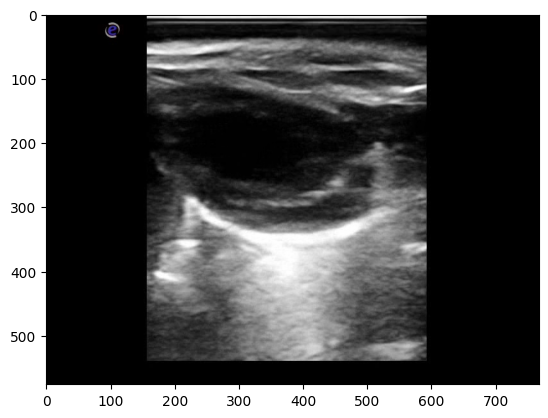

In [2]:
prueba=cv2.imread("datasets/GrupoControl/train/Diastole/AC00-02-L01_0005_diastole.jpg")
plt.imshow(prueba)
prueba.shape

(144, 192, 3)

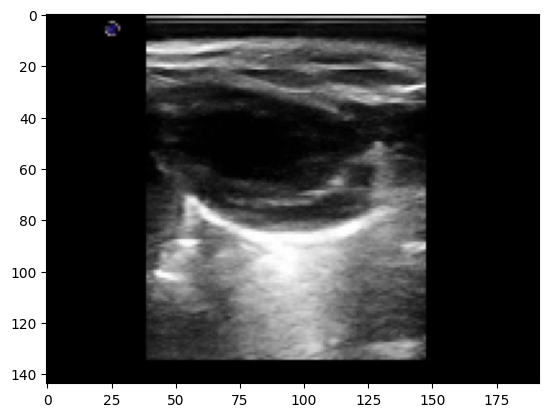

In [3]:
pruebaResize=cv2.resize(prueba, (0, 0), fx = 0.25, fy = 0.25)
plt.imshow(pruebaResize)
pruebaResize.shape

In [4]:
def custom_loss(beta):
    def loss_function(y_true, y_pred):
        # Error cuadrático medio (MSE)
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        
        # Diferencia media entre etiquetas reales y predichas
        mean_diff = tf.reduce_mean(y_true - y_pred)
        
        # Pérdida total
        loss = mse + beta * tf.abs(mean_diff)
        return loss
    return loss_function

In [31]:
# Crear el modelo
model = Sequential()
model.add(Input(shape=(144, 192, 1)))
# Capas convolucionales
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#Capa densa
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))
# Compilar el modelo
optimizer = Adam(learning_rate=1e-3)  
beta=0.2
model.compile(optimizer=optimizer, loss=custom_loss(beta), metrics=['precision', AUC()])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 144, 192, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 72, 96, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 72, 96, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 36, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 36, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 18, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 13824)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │          13,825 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,177 (164.75 KB)

 Trainable params: 42,177 (164.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
train_dir = 'datasets/GrupoControl/train/'
test_dir='datasets/GrupoControl/test/'
# Configuración de augmentación de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Escala los píxeles entre 0 y 255
    shear_range=0.2,             # Cizallamiento aleatorio
    zoom_range=0.2,              # Zoom aleatorio
    horizontal_flip=True,        # Inversión horizontal aleatoria
    fill_mode='nearest'          # Método de relleno
)

test_datagen = ImageDataGenerator(rescale=1./255)  # Normalización

# Generadores de datos de entrenamiento y validación
batch_size_train = 30  # Tamaño de lote ajustado

train_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    batch_size=batch_size_train,
    class_mode='binary'
)
batch_size_val = 30
test_generator = test_datagen.flow_from_directory(
    test_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    batch_size=batch_size_val,
    class_mode='binary'
)

Found 623 images belonging to 2 classes.
Found 157 images belonging to 2 classes.


In [32]:
import os
import numpy as np
from sklearn.model_selection import KFold
from tensorflow.keras.models import clone_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

# Extraer rutas y etiquetas de train_dir
train_filepaths = []
train_labels = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            train_filepaths.append(os.path.join(class_path, file_name))
            train_labels.append(class_name)

train_filepaths = np.array(train_filepaths)
train_labels = np.array(train_labels)

# Configurar KFold
k = 7
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Guardar métricas y pesos
fold_metrics = []
weights_dir = "fold_weights_beta1"
os.makedirs(weights_dir, exist_ok=True)

# Validación cruzada
fold_num = 1
for train_index, val_index in kf.split(train_filepaths):
    print(f"\nFold {fold_num}/{k}")
    
    # Crear subconjuntos de entrenamiento y validación
    X_train, X_val = train_filepaths[train_index], train_filepaths[val_index]
    y_train, y_val = train_labels[train_index], train_labels[val_index]
    
    # Crear generadores
    train_dataframe = pd.DataFrame({'filename': X_train, 'class': y_train})
    val_dataframe = pd.DataFrame({'filename': X_val, 'class': y_val})
    
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_dataframe,
        x_col='filename',
        y_col='class',
        target_size=(144, 192),
        color_mode='grayscale',
        class_mode='binary',
        batch_size=batch_size_train
    )
    val_generator = test_datagen.flow_from_dataframe(
        dataframe=val_dataframe,
        x_col='filename',
        y_col='class',
        target_size=(144, 192),
        color_mode='grayscale',
        class_mode='binary',
        batch_size=batch_size_val
    )
    
    
    # Configuración del optimizador con tasa de aprendizaje baja
    optimizer = Adam(learning_rate=1e-3)
    beta=0.1
    current_model = clone_model(model)
    current_model.compile(optimizer=optimizer, loss=custom_loss(beta), metrics=['precision', AUC()])
    
    # Entrenar
    history = current_model.fit(
        train_generator,
        epochs=30,
        validation_data=val_generator,
        verbose=1
    )
    
    # Guardar métricas
    fold_metrics.append(history.history)
    
    # Guardar pesos
    # Guardar pesos
    weight_file = os.path.join(weights_dir, f"fold_{fold_num}_weights.weights.h5")
    current_model.save_weights(weight_file)
    
    fold_num += 1

# Guardar métricas en un archivo para análisis posterior
import json
with open("fold_metrics_beta1.json", "w") as f:
    json.dump(fold_metrics, f)





Fold 1/7
Found 533 validated image filenames belonging to 2 classes.
Found 90 validated image filenames belonging to 2 classes.


C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 874ms/step - auc_9: 0.4362 - loss: 0.2656 - precision: 0.4913 - val_auc_9: 0.5500 - val_loss: 0.2537 - val_precision: 0.0000e+00
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 790ms/step - auc_9: 0.4863 - loss: 0.2596 - precision: 0.0000e+00 - val_auc_9: 0.5794 - val_loss: 0.2544 - val_precision: 0.0000e+00
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 807ms/step - auc_9: 0.4649 - loss: 0.2576 - precision: 0.0000e+00 - val_auc_9: 0.5543 - val_loss: 0.2547 - val_precision: 0.0000e+00
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 859ms/step - auc_9: 0.5300 - loss: 0.2556 - precision: 0.4378 - val_auc_9: 0.6190 - val_loss: 0.2525 - val_precision: 1.0000
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 791ms/step - auc_9: 0.5613 - loss: 0.2560 - precision: 0.8316 - val_auc_9: 0.6560 - val_loss: 0.2512 - val_precision: 0.0000e+00
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 796ms/step - auc_9: 0.5834 - loss: 0.2531 - precision: 0.4469 - val_auc_9: 0.6565 - val_loss: 0.250

C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 862ms/step - auc_10: 0.4844 - loss: 0.2616 - precision: 0.4933 - val_auc_10: 0.4947 - val_loss: 0.2597 - val_precision: 0.2222
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 779ms/step - auc_10: 0.4950 - loss: 0.2550 - precision: 0.2708 - val_auc_10: 0.5323 - val_loss: 0.2560 - val_precision: 0.0000e+00
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 799ms/step - auc_10: 0.5067 - loss: 0.2566 - precision: 0.3108 - val_auc_10: 0.5857 - val_loss: 0.2587 - val_precision: 0.3571
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 789ms/step - auc_10: 0.5442 - loss: 0.2576 - precision: 0.5098 - val_auc_10: 0.5876 - val_loss: 0.2539 - val_precision: 0.4444
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 782ms/step - auc_10: 0.5468 - loss: 0.2565 - precision: 0.6118 - val_auc_10: 0.5870 - val_loss: 0.2659 - val_precision: 0.3974
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 786ms/step - auc_10: 0.6333 - loss: 0.2533 - precision: 0.5427 - val_auc_10: 0.6132 - val_loss: 0.2442 - val_

...

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 886ms/step - auc_13: 0.4846 - loss: 0.2614 - precision: 0.5445 - val_auc_13: 0.5010 - val_loss: 0.2551 - val_precision: 0.4706
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 847ms/step - auc_13: 0.4972 - loss: 0.2560 - precision: 0.4288 - val_auc_13: 0.4644 - val_loss: 0.2593 - val_precision: 0.0000e+00
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 814ms/step - auc_13: 0.5135 - loss: 0.2557 - precision: 0.5263 - val_auc_13: 0.4884 - val_loss: 0.2671 - val_precision: 0.0000e+00
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 819ms/step - auc_13: 0.5465 - loss: 0.2528 - precision: 0.4403 - val_auc_13: 0.5101 - val_loss: 0.2510 - val_precision: 0.5538
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 802ms/step - auc_13: 0.5636 - loss: 0.2553 - precision: 0.4939 - val_auc_13: 0.5351 - val_loss: 0.2543 - val_precision: 0.5422
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 797ms/step - auc_13: 0.5877 - loss: 0.2565 - precision: 0.4989 - val_auc_13: 0.5670 - val_loss: 0.2600 - 

C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 837ms/step - auc_14: 0.3764 - loss: 0.2687 - precision: 0.2632 - val_auc_14: 0.4416 - val_loss: 0.2555 - val_precision: 0.0000e+00
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 790ms/step - auc_14: 0.5463 - loss: 0.2561 - precision: 0.5295 - val_auc_14: 0.4242 - val_loss: 0.2558 - val_precision: 0.2857
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 838ms/step - auc_14: 0.5156 - loss: 0.2541 - precision: 0.5350 - val_auc_14: 0.4039 - val_loss: 0.2543 - val_precision: 0.2857
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 831ms/step - auc_14: 0.5357 - loss: 0.2578 - precision: 0.5580 - val_auc_14: 0.3921 - val_loss: 0.2562 - val_precision: 0.2500
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 787ms/step - auc_14: 0.5435 - loss: 0.2547 - precision: 0.4372 - val_auc_14: 0.4024 - val_loss: 0.2531 - val_precision: 0.0000e+00
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 819ms/step - auc_14: 0.5304 - loss: 0.2576 - precision: 0.3648 - val_auc_14: 0.4316 - val_loss: 0.2543 - 

C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 858ms/step - auc_15: 0.4571 - loss: 0.2647 - precision: 0.4568 - val_auc_15: 0.4795 - val_loss: 0.2567 - val_precision: 0.0000e+00
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 781ms/step - auc_15: 0.4543 - loss: 0.2610 - precision: 0.3441 - val_auc_15: 0.5465 - val_loss: 0.2545 - val_precision: 0.0000e+00
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 777ms/step - auc_15: 0.4578 - loss: 0.2599 - precision: 0.2846 - val_auc_15: 0.5220 - val_loss: 0.2637 - val_precision: 0.0000e+00
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 770ms/step - auc_15: 0.5097 - loss: 0.2560 - precision: 0.2132 - val_auc_15: 0.5919 - val_loss: 0.2546 - val_precision: 0.4857
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 797ms/step - auc_15: 0.5731 - loss: 0.2549 - precision: 0.5160 - val_auc_15: 0.6184 - val_loss: 0.2554 - val_precision: 0.0000e+00
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 814ms/step - auc_15: 0.5064 - loss: 0.2567 - precision: 0.4675 - val_auc_15: 0.6114 - val_loss: 0

In [80]:
import pandas as pd

# Cargar el archivo JSON a un DataFrame
fold_metrics_beta1 = pd.read_json("fold_metrics_beta1.json")


fold_metrics_beta1["auc_9"][0][-1]
auc_beta1=[]
loss_beta1=[]
precision_beta1=[]
aucVal_beta1=[]
lossVal_beta1=[]
precisionVal_beta1=[]

k=9
for i in range(0,7):
    auc_beta1.append(fold_metrics_beta1[f"auc_{k}"][i][-1])
    loss_beta1.append(fold_metrics_beta1["loss"][i][-1])
    precision_beta1.append(fold_metrics_beta1["precision"][i][-1])
    aucVal_beta1.append(fold_metrics_beta1[f"val_auc_{k}"][i][-1])
    lossVal_beta1.append(fold_metrics_beta1["val_loss"][i][-1])
    precisionVal_beta1.append(fold_metrics_beta1["val_precision"][i][-1])
    k=k+1

# Crear el DataFrame
data = {
    "ROC/Entrenamiento": auc_beta1,
    "Pérdida/Entrenamiento": loss_beta1,
    "Precisión/Entrenamiento": precision_beta1,
    "ROC/Validacion": aucVal_beta1,
    "Pérdida/Validacion": lossVal_beta1,
    "Precisión/Validacion": precisionVal_beta1
}

df = pd.DataFrame(data)
#df.to_excel("beta1.xlsx", index=False)
df

,ROC/Entrenamiento,Pérdida/Entrenamiento,Precisión/Entrenamiento,ROC/Validacion,Pérdida/Validacion,Precisión/Validacion
0,0.923236,0.115056,0.837736,0.909408,0.127740,0.935484
1,0.888976,0.143351,0.797794,0.936508,0.139562,0.711111
2,0.903327,0.131366,0.839357,0.859343,0.160224,0.829268
3,0.920531,0.114122,0.856540,0.957317,0.099994,0.851852
4,0.906874,0.125724,0.842324,0.928969,0.111626,0.925000
5,0.886415,0.142781,0.794118,0.886316,0.146530,0.812500
6,0.921181,0.119857,0.835249,0.955808,0.104418,0.854167


In [71]:
df.describe()

,ROC/Entrenamiento,Pérdida/Entrenamiento,Precisión/Entrenamiento,ROC/Validacion,Pérdida/Validacion,Precisión/Validacion
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,0.907220,0.127465,0.829017,0.919096,0.127156,0.845626
std,0.015327,0.012214,0.023626,0.036396,0.022800,0.075217
min,0.886415,0.114122,0.794118,0.859343,0.099994,0.711111
25%,0.896151,0.117456,0.816522,0.897862,0.108022,0.820884
50%,0.906874,0.125724,0.837736,0.928969,0.127740,0.851852
75%,0.920856,0.137073,0.840841,0.946158,0.143046,0.889583
max,0.923236,0.143351,0.856540,0.957317,0.160224,0.935484


In [1]:
import pandas as pd

# Cargar el archivo JSON a un DataFrame
fold_metrics_beta2 = pd.read_json("fold_metrics_beta2.json")

auc_beta2=[]
loss_beta2=[]
precision_beta2=[]
aucVal_beta2=[]
lossVal_beta2=[]
precisionVal_beta2=[]
auc_beta2.append(fold_metrics_beta2["auc"][0][-1])
aucVal_beta2.append(fold_metrics_beta2["val_auc"][0][-1])
for i in range(0,7):
    if i>0:
        auc_beta2.append(fold_metrics_beta2[f"auc_{i}"][i][-1])
        aucVal_beta2.append(fold_metrics_beta2[f"val_auc_{i}"][i][-1])
    loss_beta2.append(fold_metrics_beta2["loss"][i][-1])
    precision_beta2.append(fold_metrics_beta2["precision"][i][-1])
    lossVal_beta2.append(fold_metrics_beta2["val_loss"][i][-1])
    precisionVal_beta2.append(fold_metrics_beta2["val_precision"][i][-1])
   

# Crear el DataFrame
data2 = {
    "ROC/Entrenamiento": auc_beta2,
    "Pérdida/Entrenamiento": loss_beta2,
    "Precisión/Entrenamiento": precision_beta2,
    "ROC/Validacion": aucVal_beta2,
    "Pérdida/Validacion": lossVal_beta2,
    "Precisión/Validacion": precisionVal_beta2
}

df2 = pd.DataFrame(data2)
#df2.to_excel("beta2.xlsx", index=False)
df2


,ROC/Entrenamiento,Pérdida/Entrenamiento,Precisión/Entrenamiento,ROC/Validacion,Pérdida/Validacion,Precisión/Validacion
0,0.926049,0.120806,0.862348,0.921105,0.120558,0.800000
1,0.805968,0.201176,0.737903,0.838889,0.186712,0.928571
2,0.860351,0.169721,0.781893,0.793939,0.187003,0.687500
3,0.633805,0.253656,0.557522,0.706555,0.243452,0.592105
4,0.802894,0.205130,0.716738,0.808140,0.201544,0.677419
5,0.868698,0.160346,0.792000,0.917895,0.129118,0.761905
6,0.760919,0.223199,0.707763,0.875252,0.198879,0.672131


"{sys.executable}" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [75]:
df2.describe()

,ROC/Entrenamiento,Pérdida/Entrenamiento,Precisión/Entrenamiento,ROC/Validacion,Pérdida/Validacion,Precisión/Validacion
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,0.808384,0.190576,0.736595,0.837396,0.181038,0.731376
std,0.093942,0.043940,0.095070,0.076143,0.042926,0.109750
min,0.633805,0.120806,0.557522,0.706555,0.120558,0.592105
25%,0.781907,0.165033,0.712250,0.801040,0.157915,0.674775
50%,0.805968,0.201176,0.737903,0.838889,0.187003,0.687500
75%,0.864525,0.214165,0.786947,0.896574,0.200212,0.780952
max,0.926049,0.253656,0.862348,0.921105,0.243452,0.928571


In [38]:
# Configuración del optimizador con tasa de aprendizaje baja
optimizer = Adam(learning_rate=1e-3)
beta=0.2
# Compilación del modelo
model.compile(optimizer=optimizer, loss=custom_loss(beta), metrics=['precision',AUC()])

# Entrenamiento del modelo
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator
)


C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 871ms/step - auc_1: 0.4882 - loss: 0.2638 - precision: 0.5085 - val_auc_1: 0.4957 - val_loss: 0.2646 - val_precision: 0.4815
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 781ms/step - auc_1: 0.4608 - loss: 0.2742 - precision: 0.4739 - val_auc_1: 0.4686 - val_loss: 0.2682 - val_precision: 0.4821
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 843ms/step - auc_1: 0.5739 - loss: 0.2661 - precision: 0.5530 - val_auc_1: 0.4799 - val_loss: 0.2631 - val_precision: 0.4835
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 802ms/step - auc_1: 0.5406 - loss: 0.2666 - precision: 0.5231 - val_auc_1: 0.4798 - val_loss: 0.2727 - val_precision: 0.4771
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 876ms/step - auc_1: 0.6373 - loss: 0.2586 - precision: 0.6147 - val_auc_1: 0.4820 - val_loss: 0.2782 - val_precision: 0.4200
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 829ms/step - auc_1: 0.6358 - loss: 0.2491 - precision: 0.6077 - val_auc_1: 0.5228 - val_loss: 0.2668 - val_precision: 0.534

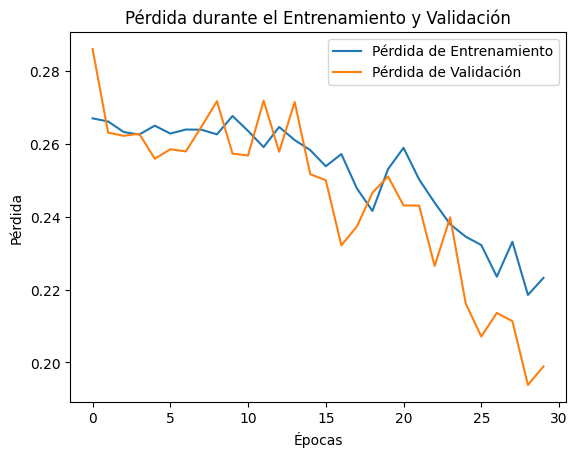

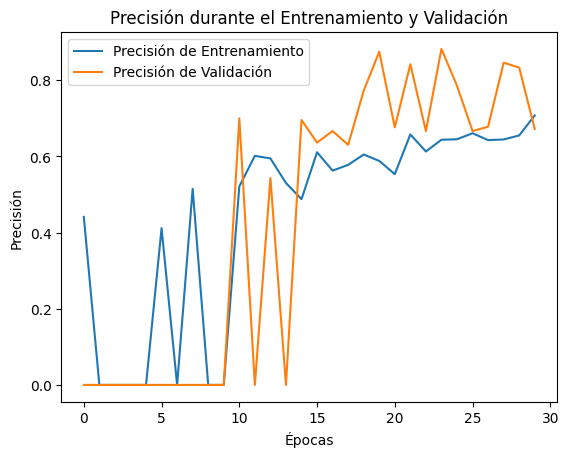

In [21]:
# Grafica la pérdida de entrenamiento y de validación
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Pérdida durante el Entrenamiento y Validación')
plt.show()

# Grafica la precisión de entrenamiento y de validación
plt.plot(history.history['precision'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_precision'], label='Precisión de Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el Entrenamiento y Validación')
plt.show()

In [22]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    class_mode='binary',
    shuffle=False
)

# Predecir entrenamiento
predictions=model.predict(train_generator)

# Pasar de probabilidad a etiquetas
train_predicted_classes = (predictions > 0.5).astype(int)  
train_true_classes = train_generator.classes

Found 623 images belonging to 2 classes.


C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 391ms/step


In [2]:
train_cm = confusion_matrix(train_true_classes, train_predicted_classes)
ConfusionMatrixDisplay(train_cm, display_labels=train_generator.class_indices.keys()).plot(cmap="binary")
plt.title("Matriz de Confusión - Entrenamiento")
plt.show()

NameError: name 'confusion_matrix' is not defined

In [24]:
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    batch_size=batch_size_val,
    class_mode='binary',
    shuffle=False
)

# Prediccion de datos de validacion
predictions=model.predict(validation_generator)

# Pasar de probabilidad a etiquetas
validation_predicted_classes = (predictions > 0.5).astype(int)  # Para problemas de clasificación binaria
validation_true_classes = validation_generator.classes

NameError: name 'validation_datagen' is not defined

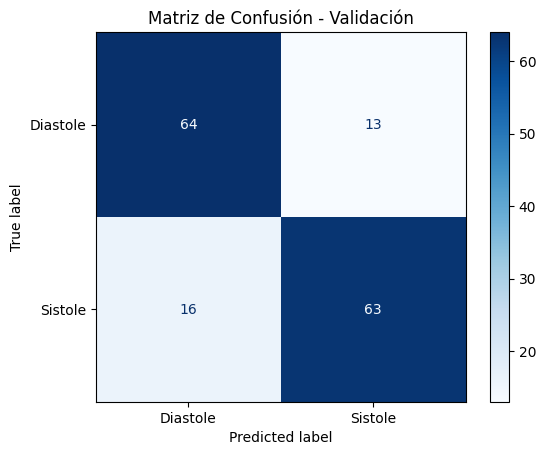

In [49]:
validation_cm = confusion_matrix(validation_true_classes, validation_predicted_classes)
ConfusionMatrixDisplay(validation_cm, display_labels=validation_generator.class_indices.keys()).plot(cmap="Blues")
plt.title("Matriz de Confusión - Validación")
plt.show()

In [25]:
test_dir="datasets/GrupoControl/test/"
test_generator = train_datagen.flow_from_directory(
    test_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    class_mode='binary',
    shuffle=False
)

# Predecir datatest
predictions=model.predict(test_generator)

# Pasar de probabilidad a etiquetas
test_predicted_classes = (predictions > 0.5).astype(int) 
test_true_classes = test_generator.classes

Found 157 images belonging to 2 classes.


C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step


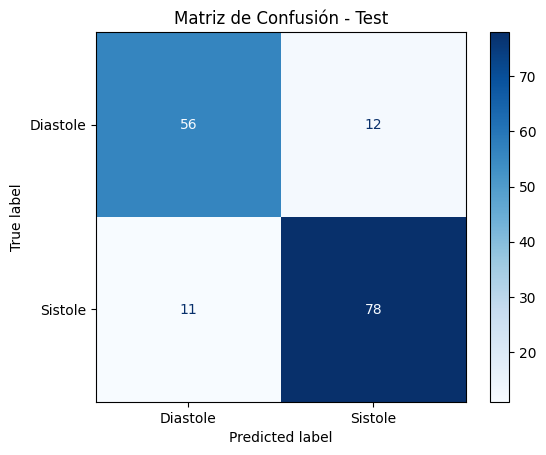

In [26]:
test_cm = confusion_matrix(test_true_classes, test_predicted_classes)
ConfusionMatrixDisplay(test_cm, display_labels=test_generator.class_indices.keys()).plot(cmap="Blues")
plt.title("Matriz de Confusión - Test")
plt.show()

In [3]:
from sklearn import metrics
# Probabilidades predichas
y_pred_prob = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)

# Etiquetas verdaderas
y_true = test_generator.classes

# Calcula la curva ROC (sin indexar si es salida sigmoid)
fpr, tpr, thresholds =metrics.roc_curve(y_true, y_pred_prob)

# Calcula el área bajo la curva (AUC)
roc_auc = metrics.auc(fpr, tpr)

# Grafica la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Línea diagonal
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.tight_layout()
plt.grid()
plt.show()



NameError: name 'model' is not defined